# 01 — FNSPID firm-day panel (S1)

Builds one news-bearing firm-day panel for the FNSPID coherent cohort:
scored headlines (Moment-2 checkpoint) ∩ adjusted open ∩ SPY, with the
LSEG earnings calendar left-joined.

**No modelling.** Attrition table + coverage figures only. Licensed
headline text is not written into the panel file.

Timing: news `session_date` is inherited from the Gate-1 revised
next-session mapping already applied in the FinBERT checkpoint. Earnings
use BMO → same session / AMC → next session.

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "pyproject.toml").exists():
    raise RuntimeError("run from repo root or final_experiments/")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.panel import (  # noqa: E402
    PanelPaths,
    build_fnspid_firm_day_panel,
    coverage_breaks_by_month,
    write_panel_outputs,
)

try:
    from IPython.display import display
except ImportError:  # pragma: no cover

    def display(obj: object) -> None:
        print(obj)


plt.rcParams.update(
    {
        "figure.figsize": (9.5, 4.2),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 11,
    }
)

OUTPUT_DIR = REPO_ROOT / "final_experiments" / "outputs" / "01_panel"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("output:", OUTPUT_DIR)

output: /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/01_panel


## 1. Build

In [2]:
paths = PanelPaths(output_dir=OUTPUT_DIR)
panel, attrition, meta = build_fnspid_firm_day_panel(paths)
written = write_panel_outputs(panel, attrition, meta, OUTPUT_DIR)

print(
    f"panel rows={meta['n_rows']:,}  symbols={meta['n_symbols']:,}  "
    f"sessions={meta['n_sessions']:,}  earnings share={meta['earnings_session_share']:.2%}"
)
display(attrition)
display(pd.Series({k: meta[k] for k in (
    "n_rows",
    "n_symbols",
    "n_sessions",
    "earnings_session_share",
    "missing_price_symbols",
    "proposed_chronological_split",
)}, name="manifest_highlights"))

panel rows=715,546  symbols=570  sessions=3,262  earnings share=2.46%


,step,surviving,note
0,cohort_symbols,574,/Users/peterprendergast/Documents/Sentiment_Di...
1,events_in_checkpoint,1640796,
2,events_after_parse,1640796,
3,events_in_cohort,1640796,
4,firm_days_news,736596,
5,symbols_with_news,574,
6,firm_days_after_news_aggregate,736596,
7,cohort_symbols_with_prices,571,"missing=['SEE', 'SKYW', 'SOL']"
8,firm_days_after_price_inner_join,715546,news ∩ adjusted_open
9,firm_days_after_spy_join,715546,session must have SPY open


n_rows                                                                     715546
n_symbols                                                                     570
n_sessions                                                                   3262
earnings_session_share                                                   0.024583
missing_price_symbols                                            [SEE, SKYW, SOL]
proposed_chronological_split    {'development_end': '2019-12-31', 'evaluation_...
Name: manifest_highlights, dtype: object

## 2. Attrition read

The executable panel is the **intersection** of cohort news days and a
tradable adjusted open (plus SPY on that session). That selection is a
collider — stated here, not solved here.

In [3]:
attrition = attrition.copy()
attrition["lost"] = attrition["surviving"].shift(1) - attrition["surviving"]
display(attrition)

,step,surviving,note,lost
0,cohort_symbols,574,/Users/peterprendergast/Documents/Sentiment_Di...,NaN
1,events_in_checkpoint,1640796,,-1640222.0
2,events_after_parse,1640796,,0.0
3,events_in_cohort,1640796,,0.0
4,firm_days_news,736596,,904200.0
5,symbols_with_news,574,,736022.0
6,firm_days_after_news_aggregate,736596,,-736022.0
7,cohort_symbols_with_prices,571,"missing=['SEE', 'SKYW', 'SOL']",736025.0
8,firm_days_after_price_inner_join,715546,news ∩ adjusted_open,-714975.0
9,firm_days_after_spy_join,715546,session must have SPY open,0.0


## 3. Coverage

months with >3× consecutive article-count change: 0


,month,article_count,prev,fold_change,break_gt_fold


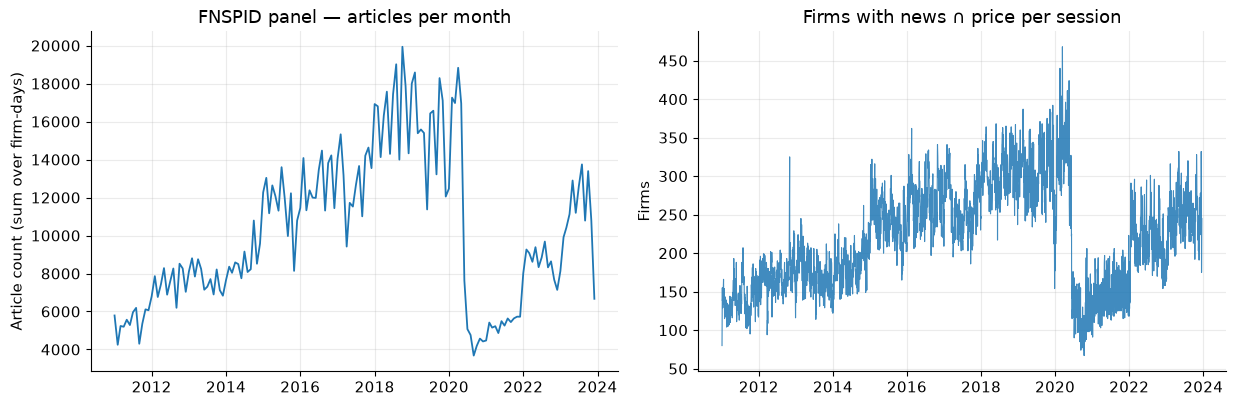

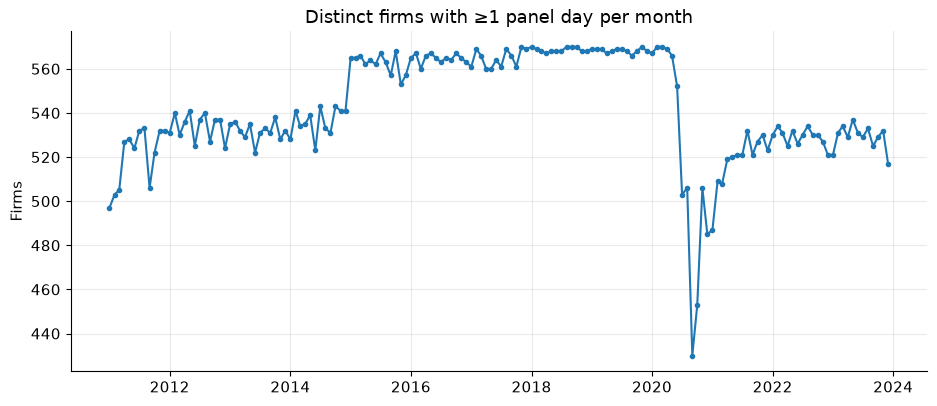

,firm_days,article_mass,share_firm_days,share_article_mass
n_bin,,,,
1,362438,362438,0.506519,0.226602
2-5,311647,848956,0.435537,0.530780
6-20,39703,337824,0.055486,0.211212
21-75,1745,48478,0.002439,0.030309
76+,13,1755,0.000018,0.001097


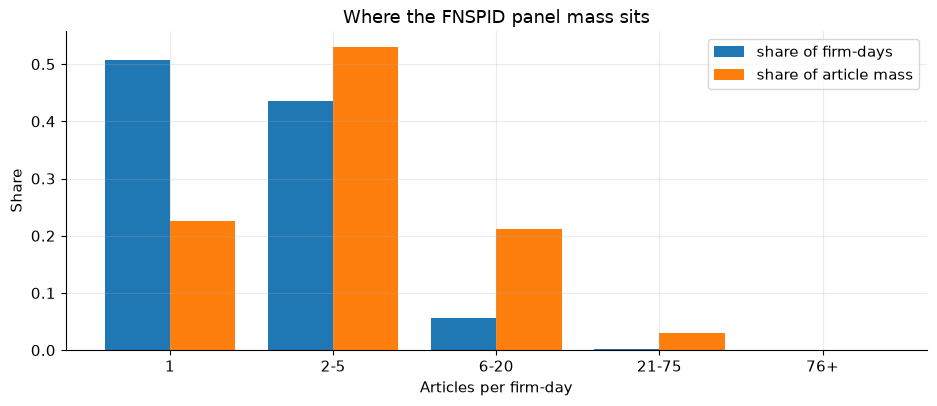

In [4]:
monthly = coverage_breaks_by_month(panel)
breaks = monthly.loc[monthly["break_gt_fold"].fillna(False)]
print(f"months with >3× consecutive article-count change: {len(breaks)}")
display(breaks.head(12))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
axes[0].plot(monthly["month"], monthly["article_count"], lw=1.3)
axes[0].set_title("FNSPID panel — articles per month")
axes[0].set_ylabel("Article count (sum over firm-days)")

firms_per_session = panel.groupby("session_date")["symbol"].nunique()
axes[1].plot(firms_per_session.index, firms_per_session.values, lw=0.8, alpha=0.85)
axes[1].set_title("Firms with news ∩ price per session")
axes[1].set_ylabel("Firms")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "coverage_monthly_and_firms.png", dpi=140)
plt.show()

# Firm-month heatmap mass
firm_month = (
    panel.assign(month=panel["session_date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["symbol", "month"], observed=True)
    .size()
    .rename("n_days")
    .reset_index()
)
per_month_firms = firm_month.groupby("month")["symbol"].nunique()
fig, ax = plt.subplots()
ax.plot(per_month_firms.index, per_month_firms.values, marker="o", ms=3)
ax.set_title("Distinct firms with ≥1 panel day per month")
ax.set_ylabel("Firms")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "coverage_firms_per_month.png", dpi=140)
plt.show()

# Article-count distribution (the low-n vs high-n mass question)
bins = [0, 1, 5, 20, 75, 10_000]
labels = ["1", "2-5", "6-20", "21-75", "76+"]
panel = panel.copy()
panel["n_bin"] = pd.cut(panel["article_count"], bins=bins, labels=labels)
n_tab = (
    panel.groupby("n_bin", observed=True)
    .agg(firm_days=("article_count", "size"), article_mass=("article_count", "sum"))
    .assign(
        share_firm_days=lambda d: d["firm_days"] / d["firm_days"].sum(),
        share_article_mass=lambda d: d["article_mass"] / d["article_mass"].sum(),
    )
)
display(n_tab)

fig, ax = plt.subplots()
ax.bar(n_tab.index.astype(str), n_tab["share_firm_days"], width=0.4, label="share of firm-days")
ax.bar(
    [i + 0.4 for i in range(len(n_tab))],
    n_tab["share_article_mass"],
    width=0.4,
    label="share of article mass",
)
ax.set_xticks([i + 0.2 for i in range(len(n_tab))], n_tab.index.astype(str))
ax.set_ylabel("Share")
ax.set_xlabel("Articles per firm-day")
ax.set_title("Where the FNSPID panel mass sits")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "firmday_n_bins.png", dpi=140)
plt.show()

## 4. Earnings overlap and split labels

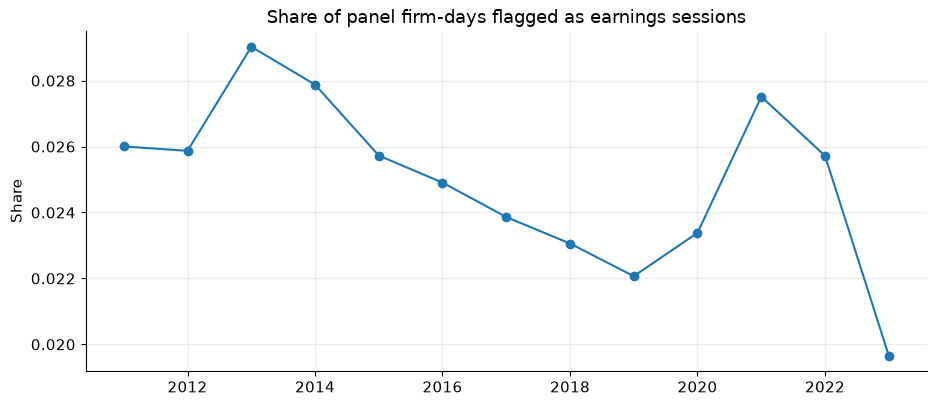

,firm_days
split,
development,512153
evaluation,203393


Proposed split is labelled only — not frozen for confirmatory scoring yet.
{
  "development_end": "2019-12-31",
  "evaluation_start": "2020-01-01",
  "status": "proposed_not_frozen_for_scoring \u2014 record before any confirmatory fit"
}


In [5]:
earn_share = (
    panel.groupby(panel["session_date"].dt.to_period("Y"))["is_earnings_session"]
    .mean()
    .rename("earnings_session_share")
)
earn_share.index = earn_share.index.to_timestamp()
fig, ax = plt.subplots()
ax.plot(earn_share.index, earn_share.values, marker="o")
ax.set_title("Share of panel firm-days flagged as earnings sessions")
ax.set_ylabel("Share")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "earnings_session_share.png", dpi=140)
plt.show()

display(panel["split"].value_counts().rename("firm_days").to_frame())
print("Proposed split is labelled only — not frozen for confirmatory scoring yet.")
print(json.dumps(meta["proposed_chronological_split"], indent=2))

## 5. Schema and caveats

In [6]:
schema = pd.DataFrame(
    {
        "column": panel.columns,
        "dtype": [str(panel[c].dtype) for c in panel.columns],
        "non_null_share": [float(panel[c].notna().mean()) for c in panel.columns],
    }
)
display(schema)
schema.to_csv(OUTPUT_DIR / "panel_schema.csv", index=False)

print("Written:")
for key, path in written.items():
    print(f"  {key}: {path}")

,column,dtype,non_null_share
0,symbol,object,1.000000
1,session_date,datetime64[ns],1.000000
2,article_count,int64,1.000000
3,recap_count,int64,1.000000
4,vader_mean,float64,1.000000
5,finbert_mean,float64,1.000000
6,finbert_negative_share,float64,1.000000
7,recap_share,float64,1.000000
8,log_article_count,float64,1.000000
9,text_kind,object,1.000000


Written:
  panel: /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/01_panel/fnspid_firm_day_panel.parquet
  attrition: /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/01_panel/attrition.csv
  manifest: /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/01_panel/manifest.json
  monthly_coverage: /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/01_panel/monthly_coverage.csv
  sample_head: /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/01_panel/panel_sample_head.csv


### Caveats (carry forward)

1. **Publisher / story_family_id / availability_timestamp** are null — the
   scored checkpoint does not carry them. A zstd rescan would be needed.
2. **News timing** is Gate-1 next-session (mostly date-only), not LSEG's
   +15‑minute open rule.
3. **Prices** are split-adjusted opens, not dividend-adjusted.
4. **Selection:** rows require news and a price — collider risk for later
   inference.
5. **Chronological split** is proposed (`dev≤2019`, `eval≥2020`) but not yet
   frozen in the plan for confirmatory scoring.